# Imports and setups

In [1]:
import tensorflow as tf
from tensorflow.python.platform import self_check

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Memory growth enabled")
    except Exception as e:
        print("Could not set memory growth:", e)

GPUs: []


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("D:/Facial Recognition/")
import cv2 
tf.config.list_physical_devices('GPU')

[]

# Creating folder structure

In [3]:
POSITIVES = os.path.join("data", "positive")
NEGATIVES = os.path.join("data", "negative")
ANCHORS = os.path.join("data", "anchors")
dirs = [POSITIVES, NEGATIVES, ANCHORS]
for dir in dirs :
    os.makedirs(dir, exist_ok = True)
print(os.path.abspath("data"))

D:\Facial Recognition\data


In [5]:
for directory in os.listdir("lfw"):
    for filename in os.listdir(os.path.join("lfw", directory)):
        EX_PATH = os.path.join("lfw", directory, filename)
        NEW_PATH = os.path.join(NEGATIVES, filename)
        os.replace(EX_PATH, NEW_PATH)

In [4]:
for filename in os.listdir(NEGATIVES):
    print(os.path.join(NEGATIVES, filename))

data\negative\Aaron_Eckhart_0001.jpg
data\negative\Aaron_Guiel_0001.jpg
data\negative\Aaron_Patterson_0001.jpg
data\negative\Aaron_Peirsol_0001.jpg
data\negative\Aaron_Peirsol_0002.jpg
data\negative\Aaron_Peirsol_0003.jpg
data\negative\Aaron_Peirsol_0004.jpg
data\negative\Aaron_Pena_0001.jpg
data\negative\Aaron_Sorkin_0001.jpg
data\negative\Aaron_Sorkin_0002.jpg
data\negative\Aaron_Tippin_0001.jpg
data\negative\Abbas_Kiarostami_0001.jpg
data\negative\Abba_Eban_0001.jpg
data\negative\Abdel_Aziz_Al-Hakim_0001.jpg
data\negative\Abdel_Madi_Shabneh_0001.jpg
data\negative\Abdel_Nasser_Assidi_0001.jpg
data\negative\Abdel_Nasser_Assidi_0002.jpg
data\negative\Abdoulaye_Wade_0001.jpg
data\negative\Abdoulaye_Wade_0002.jpg
data\negative\Abdoulaye_Wade_0003.jpg
data\negative\Abdoulaye_Wade_0004.jpg
data\negative\Abdulaziz_Kamilov_0001.jpg
data\negative\Abdullah_0001.jpg
data\negative\Abdullah_0002.jpg
data\negative\Abdullah_0003.jpg
data\negative\Abdullah_0004.jpg
data\negative\Abdullah_Ahmad_Badaw

# Accessing the WebCam using OpenCV

In [6]:
# verifying if the camera be worken
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("opened:", cap.isOpened())
ret, frame = cap.read()
print("ret:", ret)

opened: True
ret: True


In [14]:
import uuid

In [20]:
uuid.uuid1()

UUID('851bce75-8b23-11f1-b774-f09b88c055a3')

In [5]:
ANCHORS

'data\\anchors'

In [6]:
cap = cv2.VideoCapture(0)
while cap.isOpened() :
    ret, frame = cap.read()
    if not ret :
        break

    frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
    cv2.imshow("Image Collection", frame)
    # collecting the anchors
    if (cv2.waitKey(1) & 0xFF == ord('a')) :
        imgname = os.path.join(ANCHORS, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the positives
    if (cv2.waitKey(1) & 0xFF == ord('p')) :
        imgname = os.path.join(POSITIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the negatives
    if (cv2.waitKey(1) & 0xFF == ord('n')) :
        imgname = os.path.join(NEGATIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)

    if (cv2.waitKey(1) & 0xFF == ord('q')) :
        break
cap.release()
cv2.destroyAllWindows()

NameError: name 'uuid' is not defined

In [23]:
"{}.jpg".format(uuid.uuid1())

'5184b597-8b7d-11f1-9736-f09b88c055a3.jpg'

In [ ]:
import os
import cv2
import numpy as np
from IPython.display import display
from PIL import Image

PHONE_STREAM_URL = os.getenv("PHONE_STREAM_URL", "http://192.168.0.108:8080/video")
print("Using phone stream URL:", PHONE_STREAM_URL)

cap = cv2.VideoCapture(PHONE_STREAM_URL)

if not cap.isOpened():
    raise RuntimeError(
        "Could not open the phone stream.\n"
        "Check that IP Webcam is running on your phone and that the URL is correct."
    )

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

print("Phone stream opened successfully")
print("Press q in the notebook cell output to stop")

for _ in range(30):
    ret, frame = cap.read()
    if not ret:
        print("Failed to read a frame from the phone stream")
        break

    frame = cv2.resize(frame, (320, 240))
    frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(frame_rgb)
    display(img)

cap.release()

Using phone stream URL: http://192.168.0.108:8080/video


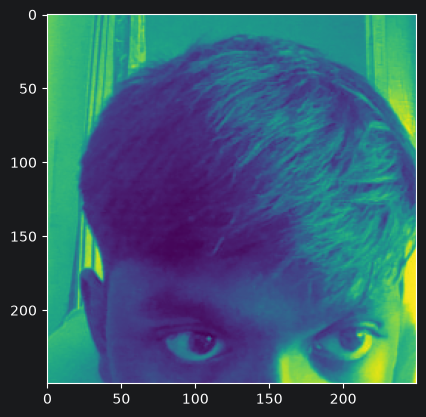

In [11]:
plt.imshow(frame[:, :, 1])